## Import

In [27]:
from pyhgf.model import Network
from scipy.stats import norm
import pandas as pd
import time
import numpy as np
from src.voting import generate_observations,generate_candidates,individual_vote,init_preferences
import altair as alt
import matplotlib.pyplot as plt
import colorsys
import altair as alt
import jax.numpy as jnp
import pandas as pd
import altair as alt
from scipy.stats import norm

# Import JAX and related modules
from jax import random, vmap
from jax.tree_util import Partial
from functools import partial as Partial

# Basic

## Parameters

In [28]:
# Parameters for the simulation
n_candidates = 3
n_preferences = 2
n_simulations = 100
n_agents = 100 * n_simulations
voting_system = "basic" # "basic", "basic (ToM)", "ranked", "quadratic"

# Generate observations, tonic volatilities, candidate and mask
input_data = generate_observations(n_nodes=n_preferences, n_steps=500, scenario=1)
tonic_volatilities = np.random.normal(-3.0, 1.0, n_agents)
candidate_list = generate_candidates(n_candidates=n_candidates, n_preferences=n_preferences)
mask = np.ones(n_candidates)

# --- Agent parameters ---
prefs = init_preferences(n_agents, n_preferences)
all_mus = prefs["mean"]         # Means of preference distributions per agent
all_pis = prefs["precision"]    # Precisions (inverse variance) per agent
all_sigmas = 1 / np.sqrt(all_pis)

## Agents

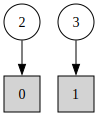

In [29]:
# Create agent preferences dynamically based on n_preferences
network = Network()

# Add binary-state nodes to the network
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network
network.plot_network()

## Round one

In [30]:
        print("--- DEBUGGING TYPES ---")
        print(f"Type of all_mus: {type(all_mus)}")
        print(f"Type of all_pis: {type(all_pis)}")
        print(f"Type of candidate_policies: {type(candidate_list)}")
        print(f"Type of tonic_volatilities: {type(tonic_volatilities)}")
        print("-------------------------")


--- DEBUGGING TYPES ---
Type of all_mus: <class 'numpy.ndarray'>
Type of all_pis: <class 'numpy.ndarray'>
Type of candidate_policies: <class 'list'>
Type of tonic_volatilities: <class 'numpy.ndarray'>
-------------------------


In [ ]:

# Create agent preferences dynamically based on n_preferences
network = Network()

# Add binary-state nodes to the network
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network
network.plot_network()

# Setup and vectorize the get_votes function for the first round
get_votes_fn = Partial(
    individual_vote,
    network=network,
    candidates=candidate_list,
    n_preferences=n_preferences,
    input_data=input_data,
    mask=mask,
    voting_system=voting_system
)
vmap_get_votes_fn = vmap(get_votes_fn)
key = random.PRNGKey(int(time.time()))
keys = random.split(key, n_agents)
votes, softmax_probs, dissatisfactions = vmap_get_votes_fn(all_mus, all_pis, tonic_volatilities, keys)


In [5]:
# Split into 1000 simulations
sim_votes = np.array_split(votes, n_simulations)
sim_diss = np.array_split(dissatisfactions, n_simulations)

# Prepare a list to store proportions and dissatisfaction for each simulation
rows = []

for i, (vote_chunk, diss_chunk) in enumerate(zip(sim_votes, sim_diss)):
    total_votes = len(vote_chunk)
    unique, counts = np.unique(vote_chunk, return_counts=True)
    
    # Compute mean dissatisfaction per candidate for this simulation
    mean_diss = np.mean(diss_chunk, axis=0)  # shape = (n_candidates,)
    mean_diss = np.array(mean_diss, dtype=float)
    for candidate, count in zip(unique, counts):
        rows.append({
            'simulation_number': i + 1,  # simulation numbers 1–100
            'candidate': candidate,
            'proportion': count / total_votes,
            'mean_dissatisfaction': mean_diss[candidate]  # ← nouvelle colonne
        })

# Convert to DataFrame
df_simulations = pd.DataFrame(rows)

# Optional: convert candidate to categorical for Altair
df_simulations['candidate'] = df_simulations['candidate'].astype('category')
df_simulations['candidate_id'] = df_simulations['candidate'].cat.codes

df_simulations

,simulation_number,candidate,proportion,mean_dissatisfaction,candidate_id
0,1,0,0.13,-20.941231,0
1,1,1,0.46,1.745030,1
2,1,2,0.41,-7.248904,2
3,2,0,0.13,-21.691292,0
4,2,1,0.61,1.184629,1
...,...,...,...,...,...
295,99,1,0.57,2.847233,1
296,99,2,0.34,-6.187919,2
297,100,0,0.10,-20.720058,0
298,100,1,0.50,2.024968,1


In [6]:
# define a global color scale for candidates
all_candidates = sorted(df_simulations['candidate_id'].unique())
color_scale = alt.Scale(domain=all_candidates, scheme='pastel1')

# interactive selections
highlight = alt.selection_point(fields=['candidate_id'], on='mouseover', empty='all')
candidate_select = alt.selection_point(fields=['candidate_id'], bind='legend', empty='all')

# create a dummy column for the legend of simulations
df_simulations["unit"] = "— = one simulation"

# identify top 2 (or winners) for each simulation
top2_winners = (
    df_simulations
    .groupby("simulation_number", group_keys=False)
    .apply(lambda x: x.nlargest(2, "proportion"))  # top 2 par simulation
)

# create df_wins before the histogram
df_wins = (
    top2_winners.groupby("candidate_id")
    .agg(
        wins=("candidate_id", "count"),
        mean_dissatisfaction=("mean_dissatisfaction", "mean")
    )
    .reset_index()
)

# chart votes
votes_chart = (
    alt.Chart(df_simulations)
    .mark_area(opacity=0.85)
    .encode(
        x=alt.X('simulation_number:N', axis=alt.Axis(labels=False, ticks=False, title=None)),
        y=alt.Y('proportion:Q', stack='center', title='Vote Proportion', axis=alt.Axis(format='.0%')),
        color=alt.Color('candidate_id:N', scale=color_scale, legend=alt.Legend(title='Candidate')),
        opacity=alt.condition(candidate_select, alt.value(1), alt.value(0.2)),
        detail="unit",
        tooltip=[
            alt.Tooltip('candidate:N', title='Candidate'),
            alt.Tooltip('proportion:Q', title='Proportion', format='.1%'),
            alt.Tooltip('mean_dissatisfaction:Q', title='Mean Dissatisfaction', format='.2f'),
            alt.Tooltip('simulation_number:N', title='Simulation'),
            alt.Tooltip('unit:N', title='Unit')
        ]
    )
    .add_params(highlight, candidate_select)
    .properties(width=1000, height=400)
)

# create a dummy legend for "— = one simulation"
legend_dash = (
    alt.Chart(df_simulations)
    .mark_point(size=100, filled=True)
    .encode(
        color=alt.Color("unit:N", legend=alt.Legend(title="Notation"))
    )
    .properties(width=50, height=50)
)

# histogram of wins
hist = (
    alt.Chart(df_wins)
    .mark_bar()
    .encode(
        x=alt.X("candidate_id:N", title="Candidate", sort="-y"),
        y=alt.Y("wins:Q", title="Number of Times in Second Round"),
        color=alt.Color("candidate_id:N", scale=color_scale, legend=None),
        opacity=alt.condition(candidate_select, alt.value(1), alt.value(0.2)),
        tooltip=[
            alt.Tooltip("candidate_id:N", title="Candidate"),
            alt.Tooltip("wins:Q", title="Number of Times in Second Round"),
            alt.Tooltip("mean_dissatisfaction:Q", title="Mean Dissatisfaction", format=".2f")
        ]
    )
    .add_params(highlight, candidate_select)
    .properties(width=300, height=400)
)

# combine the charts
combined_chart = (
    (votes_chart | hist) & legend_dash
).properties(
    title=f"Simulation Results ({voting_system.capitalize()} Voting System)"
)

combined_chart


/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_20804/1972053348.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(2, "proportion"))  # top 2 par simulation


alt.VConcatChart(...)

## Round two

In [7]:
# Group simulations to select top 2 candidates per simulation
best_two_candidates = (
    df_simulations.groupby('simulation_number', group_keys=False)
    .apply(lambda x: x.nlargest(2, 'proportion'))
)
best_two_candidates

# Group simulations to select top 2 candidates per simulation
best_two_candidates = (
    df_simulations.groupby('simulation_number', group_keys=False)
    .apply(lambda x: x.nlargest(2, 'proportion'))
)

# Iterate over each simulation
for simulation_number, sim_data in df_simulations.groupby('simulation_number'):
    
    # Get top 2 candidates for this simulation
    top_candidates = best_two_candidates.loc[
        best_two_candidates['simulation_number'] == simulation_number,
        'candidate'
    ]
    candidate_indices = top_candidates.cat.codes.values

candidate_indices
mask = jnp.zeros(n_candidates, dtype=bool).at[candidate_indices].set(True)


/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_20804/636844446.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(2, 'proportion'))
/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_20804/636844446.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(2, 'proportion'))


In [8]:
# Vectorized vote function
get_votes_fn = Partial(
        individual_vote,
        network=network,
        candidates=candidate_list,
        n_preferences=n_preferences,
        input_data=input_data,
        mask=mask,
        voting_system=voting_system
    )
vmap_get_votes_fn = vmap(get_votes_fn)

    # Random keys
key = random.PRNGKey(simulation_number)  # deterministic per simulation
keys = random.split(key, n_agents)

    # Compute votes
votes, softmax_probs, dissatisfactions = vmap_get_votes_fn(all_mus, all_pis, tonic_volatilities, keys)

In [9]:
# Split into 1000 simulations
sim_votes = np.array_split(votes, n_simulations)
sim_diss = np.array_split(dissatisfactions, n_simulations)

# Prepare a list to store proportions and dissatisfaction for each simulation
rows = []

for i, (vote_chunk, diss_chunk) in enumerate(zip(sim_votes, sim_diss)):
    total_votes = len(vote_chunk)
    unique, counts = np.unique(vote_chunk, return_counts=True)
    
    # Compute mean dissatisfaction per candidate for this simulation
    mean_diss = np.mean(diss_chunk, axis=0)  # shape = (n_candidates,)
    mean_diss = np.array(mean_diss, dtype=float)
    for candidate, count in zip(unique, counts):
        rows.append({
            'simulation_number': i + 1,  # simulation numbers 1–100
            'candidate': candidate,
            'proportion': count / total_votes,
            'mean_dissatisfaction': mean_diss[candidate]  # ← nouvelle colonne
        })

# Convert to DataFrame
df_simulations_2nd_round = pd.DataFrame(rows)

# Optional: convert candidate to categorical for Altair
df_simulations_2nd_round['candidate'] = df_simulations_2nd_round['candidate'].astype('category')
df_simulations_2nd_round['candidate_id'] = df_simulations_2nd_round['candidate'].cat.codes

df_simulations_2nd_round 

,simulation_number,candidate,proportion,mean_dissatisfaction,candidate_id
0,1,1,0.56,1.745030,0
1,1,2,0.44,-7.248904,1
2,2,1,0.70,1.184629,0
3,2,2,0.30,-7.851576,1
4,3,1,0.67,1.748040,0
...,...,...,...,...,...
195,98,2,0.42,-8.050075,1
196,99,1,0.61,2.847233,0
197,99,2,0.39,-6.187919,1
198,100,1,0.60,2.024968,0


In [10]:
# charts voting results
votes_chart = (
    alt.Chart(df_simulations_2nd_round)
    .mark_area(opacity=0.85)
    .encode(
        x=alt.X('simulation_number:N',
                axis=alt.Axis(labels=False, ticks=False, title=None)),  # pas de labels/ticks
        y=alt.Y('proportion:Q', stack='center',
                title='Vote Proportion', axis=alt.Axis(format='.0%')),
        color=alt.Color('candidate_id:N',
                        scale=color_scale,
                        legend=alt.Legend(title='Candidate')),
        opacity=alt.condition(candidate_select, alt.value(1), alt.value(0.2)),
        tooltip=[
            alt.Tooltip('candidate_id:N', title='Candidate'),
            alt.Tooltip('proportion:Q', title='Proportion', format='.1%'),
            alt.Tooltip('mean_dissatisfaction:Q', title='Mean Dissatisfaction', format='.2f'),
            alt.Tooltip('simulation_number:N', title='Simulation')
        ]
    )
    .add_params(highlight, candidate_select)
    .properties(width=1000, height=300)
)

# Identify winners
winners = df_simulations_2nd_round.loc[df_simulations_2nd_round.groupby("simulation_number")["proportion"].idxmax()]

# summary of wins and dissatisfaction
df_wins = (
    winners.groupby("candidate_id")
    .agg(
        wins=("candidate_id", "count"),
        avg_dissatisfaction=("mean_dissatisfaction", "mean")
    )
    .reset_index()
)

# Histogram of winners (same colors)
hist = (
    alt.Chart(df_wins)
    .mark_bar()
    .encode(
        x=alt.X("candidate_id:N", title="Candidate", sort="-y"),
        y=alt.Y("wins:Q", title="Number of Wins"),
        color=alt.Color("candidate_id:N",
                        scale=color_scale,
                        legend=None),  # évite double légende
        opacity=alt.condition(candidate_select, alt.value(1), alt.value(0.2)),
        tooltip=[
            alt.Tooltip("candidate_id:N", title="Candidate"),
            alt.Tooltip("wins:Q", title="Wins"),
            alt.Tooltip("avg_dissatisfaction:Q", title="Avg Dissatisfaction", format=".2f")
        ]
    )
    .add_params(highlight, candidate_select)
    .properties(width=300, height=300)
)

# create a dummy column for the legend of simulations
df_wins["unit"] = "— = one simulation"
legend_dash = (
    alt.Chart(df_wins)
    .mark_point(size=100, filled=True)
    .encode(color=alt.Color("unit:N", legend=alt.Legend(title="Notation")))
    .properties(width=50, height=50)
)

# combine the charts
combined_chart = (
    (votes_chart | hist) & legend_dash
).properties(
    title=f"Second Round Results ({voting_system.capitalize()} Voting System)"
)

combined_chart


alt.VConcatChart(...)

# Ranking

## Round one

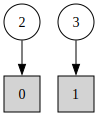

In [11]:
# Parameters for the simulation
n_candidates = 3
n_preferences = 2
n_simulations = 100
n_agents = 100 * n_simulations
voting_system = "ranked" # "basic", "basic (ToM)", "ranked", "quadratic"

# Generate observations, tonic volatilities, candidate and mask
input_data = generate_observations(n_nodes=n_preferences, n_steps=500, scenario=1)
tonic_volatilities = np.random.normal(-3.0, 1.0, n_agents)
candidate_list = generate_candidates(n_candidates=n_candidates, n_preferences=n_preferences)
mask = np.ones(n_candidates)

# --- Agent parameters ---
prefs = init_preferences(n_agents, n_preferences)
all_mus = prefs["mean"]         # Means of preference distributions per agent
all_pis = prefs["precision"]    # Precisions (inverse variance) per agent
all_sigmas = 1 / np.sqrt(all_pis)

# Create agent preferences dynamically based on n_preferences
network = Network()

# Add binary-state nodes to the network
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network
network.plot_network()

In [12]:
# Setup and vectorize the get_votes function for the first round
get_votes_fn = Partial(
    individual_vote,
    network=network,
    candidates=candidate_list,
    n_preferences=n_preferences,
    input_data=input_data,
    mask=mask,
    voting_system=voting_system
)
vmap_get_votes_fn = vmap(get_votes_fn)
key = random.PRNGKey(int(time.time()))
keys = random.split(key, n_agents)
votes, softmax_probs,dissatisfactions = vmap_get_votes_fn(all_mus, all_pis, tonic_volatilities, keys)

In [13]:
def top2_by_simulation(sim_votes):
    """
    Get the top 2 candidates per simulation based on ranked votes.
    
    Parameters:
        sim_votes (list of np.array): Each element is a simulation,
            shape = (n_agents, n_candidates), containing rankings.
            Lower rank = more preferred (0 = first choice).
    
    Returns:
        list of np.array: Top 2 candidates for each simulation (indices).
    """
    top2_list = []
    for sim in sim_votes:
        # Compute Borda-like score: sum of rankings per candidate
        scores = sim.sum(axis=0)
        # Get indices of the two candidates with the lowest score
        top2 = np.argsort(scores)[:2]
        top2_list.append(top2)
    return top2_list

# Example usage:
sim_votes = np.array_split(votes, n_simulations)  # split votes into simulations
top2_per_sim = top2_by_simulation(sim_votes)
print(top2_per_sim)

# Flatten the list of top2 arrays to count appearances
all_top2 = np.concatenate(top2_per_sim)
candidates, counts = np.unique(all_top2, return_counts=True)

[Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 1], dtype=int32), Array([2, 1], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 1], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 1], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype=int32), Array([2, 0], dtype

# ToM

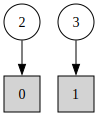

In [14]:
# Parameters for the simulation
n_candidates = 3
n_preferences = 2
n_simulations = 100
n_agents = 100 * n_simulations
voting_system = "basic" # "basic", "basic (ToM)", "ranked", "quadratic"

# Generate observations, tonic volatilities, candidate and mask
input_data = generate_observations(n_nodes=n_preferences, n_steps=500, scenario=1)
tonic_volatilities = np.random.normal(-3.0, 1.0, n_agents)
candidate_list = generate_candidates(n_candidates=n_candidates, n_preferences=n_preferences)
mask = np.ones(n_candidates)

# --- Agent parameters ---
prefs = init_preferences(n_agents, n_preferences)
all_mus = prefs["mean"]         # Means of preference distributions per agent
all_pis = prefs["precision"]    # Precisions (inverse variance) per agent
all_sigmas = 1 / np.sqrt(all_pis)

# Create agent preferences dynamically based on n_preferences
network = Network()

# Add binary-state nodes to the network
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network
network.plot_network()

In [15]:
# Setup and vectorize the get_votes function for the first round
get_votes_fn = Partial(
    individual_vote,
    network=network,
    candidates=candidate_list,
    n_preferences=n_preferences,
    input_data=input_data,
    mask=mask,
    voting_system=voting_system
)
vmap_get_votes_fn = vmap(get_votes_fn)
key = random.PRNGKey(int(time.time()))
keys = random.split(key, n_agents)
votes, softmax_probs, dissatisfactions = vmap_get_votes_fn(all_mus, all_pis, tonic_volatilities, keys)


# Split into 1000 simulations
sim_votes = np.array_split(votes, n_simulations)
sim_diss = np.array_split(dissatisfactions, n_simulations)

# Prepare a list to store proportions and dissatisfaction for each simulation
rows = []

for i, (vote_chunk, diss_chunk) in enumerate(zip(sim_votes, sim_diss)):
    total_votes = len(vote_chunk)
    unique, counts = np.unique(vote_chunk, return_counts=True)
    
    # Compute mean dissatisfaction per candidate for this simulation
    mean_diss = np.mean(diss_chunk, axis=0)  # shape = (n_candidates,)
    mean_diss = np.array(mean_diss, dtype=float)
    for candidate, count in zip(unique, counts):
        rows.append({
            'simulation_number': i + 1,  # simulation numbers 1–100
            'candidate': candidate,
            'proportion': count / total_votes,
            'mean_dissatisfaction': mean_diss[candidate]  # ← nouvelle colonne
        })

# Convert to DataFrame
df_simulations = pd.DataFrame(rows)

# Optional: convert candidate to categorical for Altair
df_simulations['candidate'] = df_simulations['candidate'].astype('category')
df_simulations['candidate_id'] = df_simulations['candidate'].cat.codes

df_simulations

average_proportions = (
    df_simulations
    .groupby('candidate')['proportion']
    .mean()
    .sort_index()  # optional: ensure candidates are in order
)

# Convert to a vector/array if needed
average_proportions_vector = average_proportions.values

average_proportions_vector

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_20804/1747502351.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('candidate')['proportion']


array([0.0844, 0.5982, 0.3174])

In [16]:
# Setup and vectorize the get_votes function for the first round
voting_system = "basic (ToM)" # "basic", "basic (ToM)", "ranked", "quadratic"
get_votes_fn = Partial(
    individual_vote,
    network=network,
    candidates=candidate_list,
    n_preferences=n_preferences,
    input_data=input_data,
    mask=mask,
    voting_system=voting_system,
    average_proportions_vector=average_proportions_vector # pass the average proportions here
)

vmap_get_votes_fn = vmap(get_votes_fn)
key = random.PRNGKey(int(time.time()))
keys = random.split(key, n_agents)
votes, softmax_probs, dissatisfactions = vmap_get_votes_fn(all_mus, all_pis, tonic_volatilities, keys)

In [17]:
# Split into 1000 simulations
sim_votes = np.array_split(votes, n_simulations)
sim_diss = np.array_split(dissatisfactions, n_simulations)

# Prepare a list to store proportions and dissatisfaction for each simulation
rows = []

for i, (vote_chunk, diss_chunk) in enumerate(zip(sim_votes, sim_diss)):
    total_votes = len(vote_chunk)
    unique, counts = np.unique(vote_chunk, return_counts=True)
    
    # Compute mean dissatisfaction per candidate for this simulation
    mean_diss = np.mean(diss_chunk, axis=0)  # shape = (n_candidates,)
    mean_diss = np.array(mean_diss, dtype=float)
    for candidate, count in zip(unique, counts):
        rows.append({
            'simulation_number': i + 1,  # simulation numbers 1–100
            'candidate': candidate,
            'proportion': count / total_votes,
            'mean_dissatisfaction': mean_diss[candidate]  # ← nouvelle colonne
        })

# Convert to DataFrame
df_simulations = pd.DataFrame(rows)

# Optional: convert candidate to categorical for Altair
df_simulations['candidate'] = df_simulations['candidate'].astype('category')
df_simulations['candidate_id'] = df_simulations['candidate'].cat.codes

df_simulations

,simulation_number,candidate,proportion,mean_dissatisfaction,candidate_id
0,1,0,0.14,-20.941231,0
1,1,1,0.62,1.745030,1
2,1,2,0.24,-7.248904,2
3,2,0,0.13,-21.691292,0
4,2,1,0.67,1.184629,1
...,...,...,...,...,...
295,99,1,0.54,2.847233,1
296,99,2,0.27,-6.187919,2
297,100,0,0.15,-20.720058,0
298,100,1,0.65,2.024968,1
